# Qwen MoE Decision Lab
### Expert routing, selective computation, weight residency, and Jev-style decisions

**Research notebook · v0.2 · 26 September 2026**

**v0.2 repair:** a failed prefix-parity check now saves diagnostics and disables cache comparisons while allowing independent experiments to finish. The 0.005 tolerance and identical-decision requirement are unchanged.

Learn which changes actually reduce **decision latency**, **resident memory**, or both, and what they do to decision quality. Every real-model arm uses bounded choices and reads answer-code logits without generating prose.

**Start in Colab:** upload this `.ipynb` at [colab.research.google.com](https://colab.research.google.com/), choose **Runtime → Change runtime type → GPU**, then **Run all**. Default: Qwen1.5-MoE-A2.7B-Chat in NF4, short inputs. For Qwen3-30B-A3B-Instruct-2507, select `qwen3_moe`; a larger GPU and sufficient download space are required. Change settings before running setup. Results are saved after every arm.

| Question | Actual experiment |
|---|---|
| Can we compute fewer experts? | Change the live per-layer top-k; compare native, half-k and top-1. |
| Are some experts reusable specialists? | Learn a per-layer allowlist from routing-fit inputs, then test untouched groups. |
| Can we skip parts of the network? | Bypass late MoE feed-forward blocks; test shared-expert-only computation where available. |
| Does that free VRAM? | Measure masking first, then physically remove excluded expert modules in a terminal experiment. |
| What makes a fast decision engine? | Compare full versus selected vocabulary projection, exact-prefix reuse, and suffix-only reduced routing. |
| Would streaming help? | Replay observed expert traces through an explicitly labeled cache/transfer simulation. |

**Evidence boundary:** this is a new exploratory MoE study. It does not promote a model or replace OpenKind's dense-Qwen roadmap. Bundled examples are authored teaching fixtures, not JevBench or fresh production evidence. With no CUDA GPU, the notebook runs tiny **random-weight** Qwen models for plumbing checks only. The pretrained GPU and NF4 paths have not been executed by the author in this environment.

## 1. Goal and scope

An MoE's active parameter count describes computation per token, not all weights resident in memory. A long prefill can touch most experts even when each token selects only a few. Attention, embeddings, routers, shared experts, routing overhead and caches still cost time or memory.

This notebook pins **Transformers 4.57.1** for its inspectable Qwen2/Qwen3 `ModuleList` expert implementations. Two runnable profiles:

| Profile | Model | Routed experts per layer / active per token | Role |
|---|---|---:|---|
| `qwen15_moe` | Qwen1.5-MoE-A2.7B-Chat | 60 / 4, plus shared expert | Smaller hardware learning profile; older model and its own license |
| `qwen3_moe` | Qwen3-30B-A3B-Instruct-2507 | 128 / 8 | More recent full-attention MoE decision experiment |

The architecture audit also inspects **Qwen3.5-35B-A3B** without downloading weights. Its packed experts, shared expert and hybrid attention/recurrent state require a different adapter. This notebook does not apply the older hooks to it or infer its quality from older Qwen results.

**Comparison rules:** one change per arm; identical model revision, precision and input population; profiling hooks removed from timed arms; all routing choices learned on `routing_fit` only; temperature fitted on `calibration`; review threshold fitted on `policy_dev`; `test` used for reporting only. There is no training or protected OpenKind final-set access.

In [24]:
# Colab settings — edit once before Run all.
import os, sys
PROFILE = "qwen15_moe"  # @param ["qwen15_moe", "qwen3_moe"]
PRECISION = "nf4"       # @param ["nf4", "bf16"]
MODEL_REVISION = ""      # Empty resolves once to an immutable Hub SHA, recorded below.
DATA_JSONL = ""          # Optional own labeled decision data; schema appears in section 4.
MOUNT_GOOGLE_DRIVE = True  # @param {type:"boolean"}
AUTO_SMOKE_ON_CPU = True    # Tiny random model if CUDA is unavailable; never a model-quality run.
MAX_INPUT_TOKENS = 768
TIMING_REPEATS = 2       # Per test request; p95 is descriptive for this small sample.
WARMUP_CALLS = 2
ALLOWLIST_FRACTION = 0.50
REVIEW_COST = 0.10       # Illustrative research utility, not a production risk limit.
RUN_WEIGHT_REMOVAL = True
RUN_QWEN35_CONFIG_AUDIT = True
RUN_LENGTH_STUDY = True
EXTRA_CONTEXT_TOKENS = [0, 128, 512]
SEED = 17
# Optional model-independent scenario grid, not measured link bandwidth.
TRANSFER_BANDWIDTH_GBPS = [8.0, 16.0, 32.0]

# Author's lightweight validation uses these environment overrides.
SMOKE_REQUESTED = os.environ.get("OPENKIND_MOE_SMOKE") == "1"
PROFILE = os.environ.get("OPENKIND_MOE_PROFILE", PROFILE)
SKIP_INSTALL = os.environ.get("OPENKIND_SKIP_INSTALL") == "1"

## 2. Setup and reproducibility

Keep Colab's installed PyTorch/CUDA pair. The setup installs the pinned model implementation and quantization tools, not another CUDA stack. If a different Transformers version was already imported, restart the Colab session and run from the top. Public checkpoints need no embedded token. NF4 comparisons are against the **same NF4 model**; they do not establish equivalence to BF16.

In [2]:
import importlib.metadata as metadata
import subprocess
required = {"transformers":"4.57.1", "accelerate":"1.10.1", "bitsandbytes":"0.48.1"}
if not SKIP_INSTALL:
    for name, wanted in required.items():
        if name in sys.modules and metadata.version(name) != wanted:
            raise RuntimeError(f"Restart the session: {name} is already imported at a different version.")
    pending=[]
    for name, wanted in required.items():
        try: installed=metadata.version(name)
        except metadata.PackageNotFoundError: installed=None
        if installed != wanted: pending.append(f"{name}=={wanted}")
    if pending:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",*pending])
    for name in ["pandas","matplotlib","psutil","safetensors"]:
        try: metadata.version(name)
        except metadata.PackageNotFoundError:
            subprocess.check_call([sys.executable,"-m","pip","install","-q",name])
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "120")

'120'

In [3]:
import copy, gc, hashlib, inspect, json, math, platform, random, shutil, time, types, warnings
from collections import OrderedDict, defaultdict
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import torch
import torch.nn.functional as F
import transformers
from transformers import (AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
                          Qwen2MoeConfig, Qwen2MoeForCausalLM, Qwen3MoeConfig, Qwen3MoeForCausalLM)
from huggingface_hub import HfApi, hf_hub_download
from IPython.display import display, Markdown
assert transformers.__version__ == "4.57.1", "This adapter requires the pinned implementation."
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
SMOKE = SMOKE_REQUESTED or (AUTO_SMOKE_ON_CPU and not torch.cuda.is_available())
DEVICE = torch.device("cpu" if SMOKE else "cuda:0")
if not SMOKE and not torch.cuda.is_available():
    raise RuntimeError("Select a Colab GPU or enable the clearly labeled CPU smoke mode.")
if SMOKE:
    torch.set_num_threads(2)
    MAX_INPUT_TOKENS=max(MAX_INPUT_TOKENS, 2048)
    TIMING_REPEATS=1
    WARMUP_CALLS=1
    print("SMOKE ONLY: tiny random Qwen weights. Accuracy and timing are NOT pretrained-model evidence.")
if MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    base=Path('/content/drive/MyDrive/Colab Notebooks/OpenKind_MoE_Lab/runs')
else:
    base=Path('/content/openkind_moe_runs') if Path('/content').exists() else Path.cwd()/'openkind_moe_runs'
RUN_DIR=base/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN_DIR.mkdir(parents=True, exist_ok=False)

def save_json(name, obj):
    target=RUN_DIR/name
    temp=target.with_suffix(target.suffix+'.tmp')
    temp.write_text(json.dumps(obj, indent=2, ensure_ascii=False, allow_nan=False))
    temp.replace(target)

def sync():
    if DEVICE.type=='cuda': torch.cuda.synchronize(DEVICE)

def memory_snapshot():
    sync()
    try: rss=psutil.Process().memory_info().rss/2**30
    except (psutil.Error, PermissionError, FileNotFoundError): rss=None
    return {"cuda_allocated_gib":torch.cuda.memory_allocated(DEVICE)/2**30 if DEVICE.type=='cuda' else None,
            "cuda_reserved_gib":torch.cuda.memory_reserved(DEVICE)/2**30 if DEVICE.type=='cuda' else None,
            "process_rss_gib":rss}

plt.rcParams.update({'figure.figsize':(9,4.5),'font.size':11,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.18})
BLUE='#285E8E'; GOLD='#B88624'; ORANGE='#C86332'; CHARCOAL='#333B43'
MANIFEST={'notebook_version':'0.2','started_utc':datetime.now(timezone.utc).isoformat(),
          'smoke_only':SMOKE,'profile':PROFILE,'precision_requested':PRECISION,
          'seed':SEED,'max_input_tokens':MAX_INPUT_TOKENS,'timing_repeats':TIMING_REPEATS,
          'review_cost':REVIEW_COST,'allowlist_fraction':ALLOWLIST_FRACTION,
          'run_length_study':RUN_LENGTH_STUDY,'extra_context_tokens':EXTRA_CONTEXT_TOKENS,
          'python':sys.version,'platform':platform.platform(),
          'torch':torch.__version__,'transformers':transformers.__version__,
          'cuda_runtime':torch.version.cuda,
          'gpu':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else None,
          'packages':{x:metadata.version(x) for x in ['transformers','accelerate','numpy','pandas']}}
save_json('manifest.json', MANIFEST)
print('Output:', RUN_DIR)
display(pd.DataFrame([memory_snapshot()]))

Output: /content/openkind_moe_runs/20260926T232551_755243Z


,cuda_allocated_gib,cuda_reserved_gib,process_rss_gib
0,0.0,0.0,1.589722


## 3. Check architecture and capacity before downloading weights

These admission estimates leave room for activations and runtime overhead, but do not guarantee a fit. Raw checkpoint downloads are much larger than a loaded NF4 model. The loader uses one GPU and **does not silently spill layers to CPU or disk**. Use a fresh runtime for another precision; run manifests keep comparisons separate.

In [4]:
PROFILES={
    'qwen15_moe':{'repo':'Qwen/Qwen1.5-MoE-A2.7B-Chat','type':'qwen2_moe',
                 'rough_billion_params':14.3,'nf4_min_free_gib':11.0,'bf16_min_free_gib':31.0},
    'qwen3_moe':{'repo':'Qwen/Qwen3-30B-A3B-Instruct-2507','type':'qwen3_moe',
                'rough_billion_params':30.5,'nf4_min_free_gib':21.0,'bf16_min_free_gib':63.0}}
SPEC=PROFILES[PROFILE]
if not SMOKE:
    info=HfApi().model_info(SPEC['repo'], revision=MODEL_REVISION or 'main', files_metadata=True)
    REVISION=info.sha
    assert len(REVISION)==40
    config_path=hf_hub_download(SPEC['repo'],'config.json',revision=REVISION)
    raw_config=json.loads(Path(config_path).read_text())
    assert raw_config.get('model_type')==SPEC['type']
    config=AutoConfig.from_pretrained(SPEC['repo'],revision=REVISION,trust_remote_code=False)
    free_vram=torch.cuda.mem_get_info(DEVICE)[0]/2**30
    required_vram=SPEC[f'{PRECISION}_min_free_gib']
    if free_vram<required_vram:
        raise RuntimeError(f"{free_vram:.1f} GiB free; profile needs at least ~{required_vram:.1f} GiB. "
                           "Choose the smaller profile or a larger GPU. No weights downloaded yet.")
    checkpoint_bytes=sum(x.size or 0 for x in info.siblings if x.rfilename.endswith('.safetensors'))
    free_disk=shutil.disk_usage(Path.home()).free
    # Conservative for a new download; cached weights may make this overestimate additional space.
    if checkpoint_bytes and free_disk < checkpoint_bytes*1.10:
        raise RuntimeError(f"Need ~{checkpoint_bytes/2**30:.1f} GiB plus download headroom; "
                           "free disk is insufficient for a fresh checkpoint.")
    MANIFEST.update(model_id=SPEC['repo'],model_revision=REVISION,config_sha256=hashlib.sha256(Path(config_path).read_bytes()).hexdigest())
    print('Pinned revision:',REVISION,'| raw weight download GiB:',round(checkpoint_bytes/2**30,2))
else:
    REVISION='random-tiny-fixture'
    C=Qwen2MoeConfig if PROFILE=='qwen15_moe' else Qwen3MoeConfig
    config=C(vocab_size=260,hidden_size=32,intermediate_size=48,num_hidden_layers=2,
             num_attention_heads=4,num_key_value_heads=2,head_dim=8,moe_intermediate_size=16,
             shared_expert_intermediate_size=24,num_experts=4,num_experts_per_tok=2,
             norm_topk_prob=(PROFILE=='qwen3_moe'),max_position_embeddings=4096,
             bos_token_id=1,eos_token_id=2,pad_token_id=0)
    config._attn_implementation='eager'
    MANIFEST.update(model_id='random-'+SPEC['type'],model_revision=REVISION)

def architecture_row(c, name):
    return {'model':name,'layers':c.num_hidden_layers,'hidden':c.hidden_size,
            'experts_per_moe_layer':c.num_experts,'top_k':c.num_experts_per_tok,
            'shared_width':getattr(c,'shared_expert_intermediate_size',0),
            'normalize_selected_router_weights':c.norm_topk_prob}
display(pd.DataFrame([architecture_row(config,MANIFEST['model_id'])]))
save_json('manifest.json',MANIFEST)

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

Pinned revision: ec052fda178e241c7c443468d2fa1db6618996be | raw weight download GiB: 26.67


,model,layers,hidden,experts_per_moe_layer,top_k,shared_width,normalize_selected_router_weights
0,Qwen/Qwen1.5-MoE-A2.7B-Chat,24,2048,60,4,5632,False


In [5]:
# Optional small config download only; this is NOT a Qwen3.5 execution path.
if RUN_QWEN35_CONFIG_AUDIT and not SMOKE:
    try:
        q35_repo='Qwen/Qwen3.5-35B-A3B'
        q35_sha=HfApi().model_info(q35_repo).sha
        q35_path=hf_hub_download(q35_repo,'config.json',revision=q35_sha)
        q35=json.loads(Path(q35_path).read_text())
        tc=q35.get('text_config',q35)
        audit={k:tc.get(k) for k in ['model_type','num_hidden_layers','hidden_size','num_experts',
                                    'num_experts_per_tok','moe_intermediate_size','shared_expert_intermediate_size','layer_types']}
        audit.update(repo=q35_repo,revision=q35_sha,scope='config audit only; no model execution')
        save_json('qwen35_config_audit.json',audit)
        display(pd.DataFrame([{k:v for k,v in audit.items() if k!='layer_types'}]))
    except Exception as exc:
        print('Optional config audit unavailable:',type(exc).__name__,str(exc)[:160])
else:
    print('Qwen3.5 audit skipped. Its packed-expert/hybrid adapter is outside this notebook.')

config.json: 0.00B [00:00, ?B/s]

,model_type,num_hidden_layers,hidden_size,num_experts,num_experts_per_tok,moe_intermediate_size,shared_expert_intermediate_size,repo,revision,scope
0,qwen3_5_moe_text,40,2048,256,8,512,512,Qwen/Qwen3.5-35B-A3B,59d61f3ce65a6d9863b86d2e96597125219dc754,config audit only; no model execution


## 4. Decision data and split checks

Supply JSONL rows with `id`, `state_id`, `family`, `split`, `state`, `question`, `options` (2–16 `{id, text}` objects), `target_id`, and `none_id` (or `null`). Split names are `routing_fit`, `calibration`, `policy_dev`, and `test`. A source document and all its related questions must stay in one split. Add your own provenance and near-duplicate audit; the exact-state check below cannot find every paraphrase.

Example schema:
```json
{"id":"doc1-q1","state_id":"doc1","family":"policy","split":"routing_fit","state":"Policy: reimburse at most $50. Receipt: $40.","question":"Is the receipt within the limit?","options":[{"id":"yes","text":"Yes"},{"id":"no","text":"No"},{"id":"unknown","text":"Insufficient evidence"}],"target_id":"yes","none_id":"unknown"}
```

If no file is supplied, the notebook creates reproducible **authored teaching fixtures** with policy, temporal and numerical facts, explicit missing information, and a small compositional family reserved for test. These teach measurement and failure analysis; they are not a Jev capability benchmark. No labels are passed to the model.

In [6]:
def teaching_fixtures():
    rng=random.Random(SEED)
    rows=[]
    sizes={'routing_fit':4,'calibration':4,'policy_dev':4,'test':8}
    if SMOKE: sizes={s:2 for s in sizes}
    serial=0
    for split,n in sizes.items():
        for j in range(n):
            serial+=1; sid=f'{split}-document-{serial}'
            family=['policy','temporal','arithmetic','composition'][j%(4 if split=='test' else 3)]
            a=10+serial; b=a+(3 if j%2 else -3)
            if family=='policy':
                state=f'Case {serial}. Policy: an amount at most {a} credits is within the limit. The receipt amount is {b} credits. Currency is credits.'
                yes=b<=a
                claims=[('Is the receipt within the policy limit?', 'yes' if yes else 'no'),
                        ('Does the receipt exceed the policy limit?', 'no' if yes else 'yes'),
                        ('Has a manager approved this receipt?', 'unknown'),
                        ('Is the receipt currency credits?', 'yes')]
            elif family=='temporal':
                state=f'Case {serial}. A filing is on time if filed on or before day {a}. It was filed on day {b}. The filing channel was online.'
                yes=b<=a
                claims=[('Was the filing on time?', 'yes' if yes else 'no'),
                        ('Was the filing late?', 'no' if yes else 'yes'),
                        ('Was a late fee paid?', 'unknown'),
                        ('Was the filing submitted on paper?', 'no')]
            elif family=='arithmetic':
                state=f'Case {serial}. Opening inventory is {a} units. Exactly 4 units arrived, then exactly 2 units were shipped. No other inventory changes occurred. The warehouse is North.'
                claims=[(f'Is closing inventory {a+2} units?', 'yes'),
                        (f'Is closing inventory {a+4} units?', 'no'),
                        ('Is the supervisor named Morgan?', 'unknown'),
                        ('Is the warehouse South?', 'no')]
            else:
                state=f'Case {serial}. Request R{serial} belongs only to account A{serial}. Account A{serial} is assigned only to team Cedar. Team Cedar is in region West. No other team owns this account.'
                claims=[(f'Is request R{serial} assigned through its account to Cedar?', 'yes'),
                        (f'Is account A{serial} assigned to team Pine?', 'no'),
                        (f'Has request R{serial} been approved?', 'unknown'),
                        ('Is the account team in region West?', 'yes')]
            for q,(question,target) in enumerate(claims):
                options=[{'id':'yes','text':'Yes: established by the supplied facts and rules.'},
                         {'id':'no','text':'No: the supplied facts and rules establish the opposite.'},
                         {'id':'unknown','text':'Insufficient information in the supplied state.'}]
                rng.shuffle(options)
                rows.append(dict(id=f'{sid}-q{q}',state_id=sid,family=family,split=split,
                                 state=state,question=question,options=options,target_id=target,none_id='unknown'))
    return rows

def validate_rows(rows):
    ids=set(); group_roles={}; state_roles={}
    for r in rows:
        for key in ['id','state_id','family','split','state','question','options','target_id','none_id']:
            if key not in r: raise ValueError(f'Missing {key}')
        assert r['id'] not in ids, 'Duplicate decision id'; ids.add(r['id'])
        assert r['split'] in {'routing_fit','calibration','policy_dev','test'}
        keys=[o['id'] for o in r['options']]
        assert 2<=len(keys)<=16 and len(keys)==len(set(keys))
        assert r['target_id'] in keys and (r['none_id'] is None or r['none_id'] in keys)
        assert all(isinstance(o['text'],str) and o['text'].strip() for o in r['options'])
        signature=hashlib.sha256(r['state'].encode()).hexdigest()
        for mapping,key in [(group_roles,r['state_id']),(state_roles,signature)]:
            assert mapping.setdefault(key,r['split'])==r['split'], 'Source state crosses splits'
    assert set(group_roles.values())=={'routing_fit','calibration','policy_dev','test'}
    # A group must represent exactly one state, even within one split.
    for sid in group_roles:
        assert len({r['state'] for r in rows if r['state_id']==sid})==1
    return rows

ROWS=validate_rows([json.loads(s) for s in Path(DATA_JSONL).read_text().splitlines() if s.strip()] if DATA_JSONL else teaching_fixtures())
DATA_KIND='user_supplied' if DATA_JSONL else 'authored_teaching_fixtures'
serialized='\n'.join(json.dumps(r,sort_keys=True,ensure_ascii=False) for r in ROWS)+'\n'
(RUN_DIR/'decisions.jsonl').write_text(serialized)
MANIFEST.update(data_kind=DATA_KIND,data_sha256=hashlib.sha256(serialized.encode()).hexdigest(),
                rows=len(ROWS),source_groups=len({r['state_id'] for r in ROWS}))
save_json('manifest.json',MANIFEST)
display(pd.DataFrame(ROWS).groupby(['split','family']).agg(decisions=('id','size'),source_groups=('state_id','nunique')))

decisions  source_groups
split       family                               
calibration arithmetic           4              1
            policy               8              2
            temporal             4              1
policy_dev  arithmetic           4              1
            policy               8              2
            temporal             4              1
routing_fit arithmetic           4              1
            policy               8              2
            temporal             4              1
test        arithmetic           8              2
            composition          8              2
            policy               8              2
            temporal             8              2

## 5. Load one model and verify the supported layout

All normal experiments retain the same weights. Routers and the output head stay unquantized so routing and selected-row projection have a transparent implementation. NF4 changes expert/dense linear weights and is a distinct numerical model. BF16 requires GPU support and much more memory.

In [7]:
class TinyTokenizer:
    """Byte tokenizer for random-weight plumbing checks only."""
    def apply_chat_template(self,messages,tokenize=False,add_generation_prompt=True,**kwargs):
        return ''.join(f"[{m['role']}]\n{m['content']}\n" for m in messages)+'[assistant]\n'
    def encode(self,text,add_special_tokens=False): return [b+4 for b in text.encode('utf-8')]
    def decode(self,ids): return bytes([i-4 for i in ids if i>=4]).decode('utf-8',errors='replace')

if SMOKE:
    M=Qwen2MoeForCausalLM if PROFILE=='qwen15_moe' else Qwen3MoeForCausalLM
    model=M(config).eval().to(DEVICE)
    tokenizer=TinyTokenizer()
    actual_dtype='float32'
else:
    tokenizer=AutoTokenizer.from_pretrained(SPEC['repo'],revision=REVISION,trust_remote_code=False)
    if PRECISION=='bf16' and not torch.cuda.is_bf16_supported():
        raise RuntimeError('This GPU does not support the requested BF16 profile. Use NF4.')
    dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    quant=None
    if PRECISION=='nf4':
        quant=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_quant_type='nf4',
              bnb_4bit_use_double_quant=True,bnb_4bit_compute_dtype=dtype,
              llm_int8_skip_modules=['lm_head','gate','shared_expert_gate'])
    model=AutoModelForCausalLM.from_pretrained(SPEC['repo'],revision=REVISION,
          trust_remote_code=False,use_safetensors=True,torch_dtype=dtype,quantization_config=quant,
          device_map={'':0},low_cpu_mem_usage=True,attn_implementation='eager').eval()
    actual_dtype=str(dtype)
    if any(p.device.type!='cuda' for p in model.parameters()):
        raise RuntimeError('Unexpected offload: this experiment requires a single resident GPU model.')
    if model.lm_head.weight.ndim!=2 or type(model.lm_head).__name__!='Linear':
        raise RuntimeError('Output head was quantized or changed; selected-row adapter must be requalified.')

MOES=[(i,layer.mlp) for i,layer in enumerate(model.model.layers)
      if type(layer.mlp).__name__ in {'Qwen2MoeSparseMoeBlock','Qwen3MoeSparseMoeBlock'}]
assert MOES and len(MOES)==config.num_hidden_layers, 'Unexpected sparse/dense layer pattern'
for _,block in MOES:
    assert isinstance(block.experts,torch.nn.ModuleList) and type(block.gate).__name__=='Linear'
    assert len(block.experts)==config.num_experts and block.top_k==config.num_experts_per_tok
    if not SMOKE and PRECISION=='nf4':
        assert any(type(m).__name__=='Linear4bit' for m in block.experts[0].modules()), 'NF4 expert conversion missing'
MODEL_PRUNED=False
MANIFEST.update(compute_dtype=actual_dtype,attention_backend='eager',
                moe_implementation_sha256=hashlib.sha256(inspect.getsource(type(MOES[0][1])).encode()).hexdigest(),
                architecture=architecture_row(config,MANIFEST['model_id']),
                native_router_normalization=bool(config.norm_topk_prob),
                loaded_memory=memory_snapshot())
save_json('manifest.json',MANIFEST)
print('Loaded:',MANIFEST['model_id'],'| MoE blocks:',len(MOES),'| native top-k:',config.num_experts_per_tok)
print('Reference eager implementation: useful for controlled interventions, not a serving-engine speed ceiling.')

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00006-of-00008.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

Loaded: Qwen/Qwen1.5-MoE-A2.7B-Chat | MoE blocks: 24 | native top-k: 4
Reference eager implementation: useful for controlled interventions, not a serving-engine speed ceiling.


## 6. Direct decision readout and correctness checks

Every prompt includes the state, question, and descriptions of all choices. Consumer option IDs and the gold label stay outside the prompt. Answer letters are checked as single tokens at the **actual answer boundary**. Inputs above the configured limit are rejected, never silently truncated.

The selected-row path projects the final hidden state onto the allowed output vocabulary rows. Compare it with a full final-position vocabulary projection first. This removes output work, not the input embedding weights. Softmax over allowed options is a conditional distribution; calibration and review are measured later.

In [8]:
LETTERS='ABCDEFGHIJKLMNOP'
SYSTEM='Read the supplied state and question. Apply only its facts and rules. Choose one listed answer. Return only its letter.'
def prepare(r):
    user='State:\n'+r['state']+'\n\nQuestion:\n'+r['question']+'\n\nChoices:\n'+'\n'.join(
        f'{LETTERS[j]}. {o["text"]}' for j,o in enumerate(r['options']))
    prompt=tokenizer.apply_chat_template([{'role':'system','content':SYSTEM},{'role':'user','content':user}],
                                        tokenize=False,add_generation_prompt=True)
    ids=tokenizer.encode(prompt,add_special_tokens=False)
    if len(ids)>MAX_INPUT_TOKENS:
        raise ValueError(f'{r["id"]}: {len(ids)} tokens exceeds {MAX_INPUT_TOKENS}; no truncation.')
    codes=[]
    for letter in LETTERS[:len(r['options'])]:
        extended=tokenizer.encode(prompt+letter,add_special_tokens=False)
        if extended[:-1]!=ids or len(extended)!=len(ids)+1:
            raise ValueError('Answer boundary is not a single appended token; repair renderer explicitly.')
        codes.append(extended[-1])
    assert len(set(codes))==len(codes)
    return ids,codes

@torch.inference_mode()
def score_ids(ids,codes,readout='selected',cache=None,cache_position=None,use_cache=False):
    inp=torch.tensor([ids],dtype=torch.long,device=DEVICE)
    kwargs={'input_ids':inp,'use_cache':use_cache,'return_dict':True}
    if cache is not None:
        kwargs.update(past_key_values=cache,cache_position=cache_position,
                      attention_mask=torch.ones((1,int(cache_position[-1])+1),device=DEVICE,dtype=torch.long))
    ix=torch.tensor(codes,device=DEVICE,dtype=torch.long)
    if readout=='full':
        out=model(**kwargs,logits_to_keep=1,output_router_logits=False)
        logits=out.logits[0,-1].index_select(0,ix)
    else:
        out=model.model(**kwargs,output_router_logits=False)
        hidden=out.last_hidden_state[0,-1]
        weights=model.lm_head.weight.index_select(0,ix)
        bias=model.lm_head.bias.index_select(0,ix) if model.lm_head.bias is not None else None
        logits=F.linear(hidden.to(weights.dtype),weights,bias)
    values=logits.float().cpu().numpy()
    if not np.isfinite(values).all(): raise FloatingPointError('Non-finite answer logits; arm is invalid')
    return values,out.past_key_values if use_cache else None

def decision(r,readout='selected'):
    ids,codes=prepare(r)
    logits,_=score_ids(ids,codes,readout=readout)
    return logits,len(ids)

def probs(logits,T=1.0):
    z=np.asarray(logits,dtype=np.float64)/T; z-=z.max()
    e=np.exp(z); return e/e.sum()

for r in ROWS: prepare(r)
probe=next(r for r in ROWS if r['split']=='routing_fit')
a,_=decision(probe,'full'); b,_=decision(probe,'selected')
dp=float(np.max(np.abs(probs(a)-probs(b))))
assert dp<=0.005 and np.argmax(a)==np.argmax(b), f'Readout parity failed: {dp}'
print('Full vs selected-row probability difference:',dp)
save_json('readout_parity.json',{'max_probability_difference':dp,'decision_match':bool(np.argmax(a)==np.argmax(b)),
                                 'scope':'one preflight item; broader differences checked in experiments'})

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Full vs selected-row probability difference: 0.0


## 7. Observe expert use before changing it

Profiling captures routed assignments, unique experts touched per layer, router entropy, and probability mass retained by native top-k. It runs only on `routing_fit`. These hooks add work and are removed before timing. Counts measure use, **not causal importance**; a frequently used expert is not automatically safe to keep in isolation.

,mean_unique_experts,mean_selected_mass,mean_entropy_nats
layer,,,
0,59.250,0.220,3.835
1,59.812,0.226,3.850
2,59.000,0.239,3.829
3,59.938,0.280,3.738
4,59.875,0.279,3.724
5,59.938,0.285,3.687
6,59.500,0.304,3.651
7,58.250,0.343,3.550
8,59.312,0.340,3.562


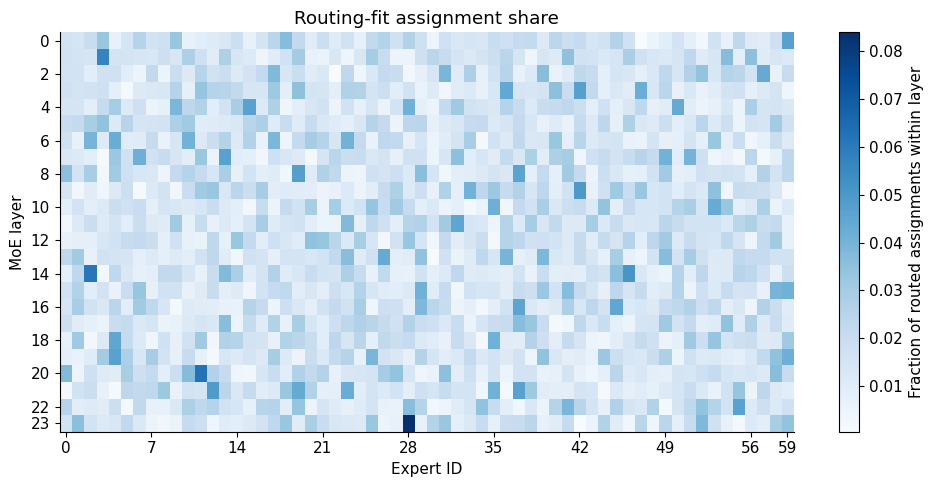

Allowlist size per layer: [30]


In [9]:
class RoutingTrace:
    def __init__(self):
        self.counts={i:np.zeros(b.num_experts,dtype=np.int64) for i,b in MOES}
        self.records=[]; self.handles=[]; self.current_id=None
    def __enter__(self):
        for layer,block in MOES:
            def observe(module,inputs,logits,layer=layer,block=block):
                with torch.no_grad():
                    p=logits.float().softmax(-1)
                    w,ix=p.topk(block.top_k,dim=-1)
                    counts=torch.bincount(ix.flatten(),minlength=block.num_experts).cpu().numpy()
                    self.counts[layer]+=counts
                    self.records.append({'id':self.current_id,'layer':layer,'tokens':int(p.shape[0]),
                        'expert_ids':np.flatnonzero(counts).tolist(),
                        'unique_experts':int(np.count_nonzero(counts)),
                        'entropy_nats':float((-(p*p.clamp_min(1e-30).log()).sum(-1)).mean().cpu()),
                        'selected_mass':float(w.sum(-1).mean().cpu())})
            self.handles.append(block.gate.register_forward_hook(observe))
        return self
    def __exit__(self,*args):
        for handle in self.handles: handle.remove()
        self.handles.clear()

with RoutingTrace() as trace:
    for r in ROWS:
        if r['split']=='routing_fit':
            trace.current_id=r['id']; decision(r)
ROUTE_COUNTS=trace.counts
TRACE=trace.records
ALLOWLISTS={i:np.argsort(-count,kind='stable')[:max(config.num_experts_per_tok,
              math.ceil(len(count)*ALLOWLIST_FRACTION))].tolist() for i,count in ROUTE_COUNTS.items()}
save_json('routing_counts.json',{str(k):v.tolist() for k,v in ROUTE_COUNTS.items()})
save_json('routing_trace.json',TRACE)
save_json('allowlists.json',{'selected_from':'routing_fit only','fraction':ALLOWLIST_FRACTION,
                            'experts':{str(k):v for k,v in ALLOWLISTS.items()}})
route_df=pd.DataFrame([{k:v for k,v in row.items() if k!='expert_ids'} for row in TRACE])
display(route_df.groupby('layer').agg(mean_unique_experts=('unique_experts','mean'),
         mean_selected_mass=('selected_mass','mean'),mean_entropy_nats=('entropy_nats','mean')).round(3))
mat=np.stack([ROUTE_COUNTS[i]/max(1,ROUTE_COUNTS[i].sum()) for i,_ in MOES])
fig,ax=plt.subplots(figsize=(10,5))
im=ax.imshow(mat,aspect='auto',cmap='Blues',interpolation='nearest')
ax.set(xlabel='Expert ID',ylabel='MoE layer',title=('SMOKE: random weights — ' if SMOKE else '')+'Routing-fit assignment share')
ax.set_xticks(sorted(set(range(0,config.num_experts,max(1,config.num_experts//8)))|{config.num_experts-1}))
ax.set_yticks(sorted(set(range(0,len(MOES),max(1,len(MOES)//12)))|{len(MOES)-1}))
ax.grid(False); fig.colorbar(im,ax=ax,label='Fraction of routed assignments within layer')
fig.tight_layout(); fig.savefig(RUN_DIR/'routing_heatmap.png',dpi=150); plt.show()
print('Allowlist size per layer:',sorted({len(v) for v in ALLOWLISTS.values()}))

## 8. Reversible interventions

`top_k` changes the live MoE block, not just a config file. Allowlist masks run **before top-k selection**, so excluded experts cannot execute. With Qwen1.5's native unnormalized top-k, reducing k also reduces retained routed probability mass; that is part of this model-changing intervention. Masking renormalizes the full softmax over the remaining experts.

Late-block bypass returns zero for the MoE contribution while preserving the decoder's attention and residual path. Shared-only keeps the learned shared expert and its gate, where present. All these arms still retain their weights in memory. Context managers restore every change even after an exception.

In [10]:
@contextmanager
def intervention(top_k=None,allowlists=None,skip_layers=(),shared_only=False):
    if MODEL_PRUNED and allowlists!=ALLOWLISTS:
        raise RuntimeError('Weights were removed. Reload the model before running an unrestricted arm.')
    saved=[]; handles=[]
    try:
        for layer,block in MOES:
            saved.append((block,block.top_k,block.forward))
            if top_k is not None:
                assert 1<=top_k<=block.num_experts
                block.top_k=int(top_k)
            if allowlists is not None:
                allowed=allowlists[layer]
                assert len(set(allowed))==len(allowed) and len(allowed)>=block.top_k
                keep=torch.zeros(block.num_experts,dtype=torch.bool,device=DEVICE)
                keep[torch.tensor(allowed,device=DEVICE)]=True
                def mask(module,inputs,output,keep=keep): return output.masked_fill(~keep,float('-inf'))
                handles.append(block.gate.register_forward_hook(mask))
            if layer in skip_layers or shared_only:
                def bypass(this,hidden_states,keep_shared=shared_only):
                    if keep_shared:
                        if not hasattr(this,'shared_expert'): raise RuntimeError('No shared expert in this family')
                        flat=hidden_states.reshape(-1,hidden_states.shape[-1])
                        result=this.shared_expert(flat)*torch.sigmoid(this.shared_expert_gate(flat))
                        return result.reshape_as(hidden_states),None
                    return torch.zeros_like(hidden_states),None
                block.forward=types.MethodType(bypass,block)
        yield
    finally:
        for handle in handles: handle.remove()
        for block,k,forward in saved:
            block.top_k=k; block.forward=forward

before,_=decision(probe)
with intervention(top_k=config.num_experts_per_tok): same,_=decision(probe)
with intervention(top_k=1): altered,_=decision(probe)
after,_=decision(probe)
assert np.max(np.abs(probs(before)-probs(same)))<=0.005
assert np.max(np.abs(probs(before)-probs(after)))<=0.005
assert all(b.top_k==config.num_experts_per_tok for _,b in MOES)
print('No-op and restoration checks pass. Altered routing is a new model behavior, not a parity claim.')
# Verify actual expert inputs, independently of the router's reported choices.
def count_routed_work(settings):
    counts={i:0 for i,_ in MOES}; handles=[]
    try:
        for i,block in MOES:
            def count(module,args,i=i): counts[i]+=int(args[0].shape[0])
            for expert in block.experts: handles.append(expert.register_forward_pre_hook(count))
        with intervention(**settings): decision(probe)
    finally:
        for handle in handles: handle.remove()
    return counts
native_work=count_routed_work({}); top1_work=count_routed_work({'top_k':1})
probe_tokens=len(prepare(probe)[0])
assert all(v==probe_tokens*config.num_experts_per_tok for v in native_work.values())
assert all(v==probe_tokens for v in top1_work.values())
work_table=pd.DataFrame({'layer':list(native_work),'native_token_expert_pairs':list(native_work.values()),
                         'top1_token_expert_pairs':list(top1_work.values())})
work_table.to_csv(RUN_DIR/'observed_expert_work.csv',index=False)
display(work_table.head(8))
print('Fewer routed token-expert pairs are confirmed; unique experts touched and wall time may still stay high.')

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


No-op and restoration checks pass. Altered routing is a new model behavior, not a parity claim.


,layer,native_token_expert_pairs,top1_token_expert_pairs
0,0,468,117
1,1,468,117
2,2,468,117
3,3,468,117
4,4,468,117
5,5,468,117
6,6,468,117
7,7,468,117


Fewer routed token-expert pairs are confirmed; unique experts touched and wall time may still stay high.


## 9. Measure quality, calibration, review and latency together

Every arm fits one temperature on `calibration`, then selects a review threshold on `policy_dev` by minimizing `wrong accepted / all + review_cost × reviewed / all`. Test labels do not affect either fit. Zero acceptance produces an undefined accepted-error rate, shown as missing.

Timing includes rendering, tokenization, inference, device synchronization and probability transfer. It excludes loading, one-time intervention setup, calibration fitting and profiling. Request p50/p95 describe this sample; they are not queue-inclusive service SLOs. CUDA allocated/reserved peaks and process RSS snapshots are different metrics. Hook-based masks include their hook overhead. The small teaching set cannot establish production safety.

In [11]:
def fit_temperature(predictions):
    temperatures=np.unique(np.r_[1.0,np.exp(np.linspace(np.log(0.25),np.log(5.0),81))])
    losses=[np.mean([-np.log(max(probs(x['logits'],T)[x['target_index']],1e-15)) for x in predictions]) for T in temperatures]
    return float(temperatures[int(np.argmin(losses))])

def row_outcome(x,T):
    p=probs(x['logits'],T); j=int(p.argmax())
    return p,j,float(p[j]),bool(j==x['target_index'])

def fit_review_threshold(predictions,T):
    conf=np.array([row_outcome(x,T)[2] for x in predictions])
    wrong=np.array([not row_outcome(x,T)[3] for x in predictions])
    choices=np.unique(np.r_[0.0,conf,1.000001])
    def objective(t):
        accept=conf>=t
        cost=float(np.mean(accept*wrong)+REVIEW_COST*np.mean(~accept))
        return cost,-float(accept.mean())
    return float(min(choices,key=objective))

def summarize(predictions,T,threshold):
    P=[row_outcome(x,T) for x in predictions]
    correct=np.array([v[3] for v in P]); confidence=np.array([v[2] for v in P])
    accept=confidence>=threshold
    nll=float(np.mean([-np.log(max(v[0][x['target_index']],1e-15)) for x,v in zip(predictions,P)]))
    brier=float(np.mean([np.sum((v[0]-np.eye(len(v[0]))[x['target_index']])**2) for x,v in zip(predictions,P)]))
    none_rows=[j for j,x in enumerate(predictions) if x['none_id'] is not None and x['target_id']==x['none_id']]
    other_rows=[j for j,x in enumerate(predictions) if x['none_id'] is not None and x['target_id']!=x['none_id']]
    predicted=[x['option_ids'][v[1]] for x,v in zip(predictions,P)]
    ece=0.0
    for lo,hi in zip(np.linspace(0,1,11)[:-1],np.linspace(0,1,11)[1:]):
        take=(confidence>=lo)&((confidence<hi) if hi<1 else (confidence<=hi))
        if take.any(): ece+=float(take.mean()*abs(correct[take].mean()-confidence[take].mean()))
    return {'n_test':len(predictions),'source_groups':len({x['state_id'] for x in predictions}),
            'accuracy':float(correct.mean()),'nll':nll,'brier':brier,'ece_10_bins':ece,
            'none_recall':float(np.mean([predicted[j]==predictions[j]['none_id'] for j in none_rows])) if none_rows else None,
            'false_none':float(np.mean([predicted[j]==predictions[j]['none_id'] for j in other_rows])) if other_rows else None,
            'coverage':float(accept.mean()),'accepted_error':float((~correct[accept]).mean()) if accept.any() else None,
            'review_cost':float(np.mean(accept*(~correct))+REVIEW_COST*np.mean(~accept))}

EVAL_ROWS=[r for r in ROWS if r['split']!='routing_fit']
# Same randomized request order in each arm; temperature fitting uses split labels afterwards.
random.Random(SEED).shuffle(EVAL_ROWS)
RESULTS=[]; PREDICTIONS={}; ARM_SETTINGS={}

def measure_call(fn):
    sync(); start=time.perf_counter(); value=fn(); sync()
    return value,1000*(time.perf_counter()-start)

def run_arm(name,settings=None,readout='selected'):
    settings=settings or {}
    predictions=[]; latency=[]
    gc.collect()
    if DEVICE.type=='cuda': torch.cuda.empty_cache()
    with intervention(**settings):
        for _ in range(WARMUP_CALLS): decision(probe,readout)
        sync()
        if DEVICE.type=='cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
        start_memory=memory_snapshot()
        for r in EVAL_ROWS:
            times=[]
            repeat=TIMING_REPEATS if r['split']=='test' else 1
            for rep in range(repeat):
                (z,n_tokens),ms=measure_call(lambda r=r:decision(r,readout))
                if rep==0: first_z=z.copy()
                times.append(ms)
            if r['split']=='test': latency.extend(times)
            keys=[o['id'] for o in r['options']]
            predictions.append({'id':r['id'],'state_id':r['state_id'],'family':r['family'],'split':r['split'],
                'target_id':r['target_id'],'none_id':r['none_id'],'option_ids':keys,'target_index':keys.index(r['target_id']),
                'logits':first_z.tolist(),'input_tokens':n_tokens,'latency_ms':times})
        peak_alloc=torch.cuda.max_memory_allocated(DEVICE)/2**30 if DEVICE.type=='cuda' else None
        peak_reserved=torch.cuda.max_memory_reserved(DEVICE)/2**30 if DEVICE.type=='cuda' else None
    T=fit_temperature([x for x in predictions if x['split']=='calibration'])
    threshold=fit_review_threshold([x for x in predictions if x['split']=='policy_dev'],T)
    tests=[x for x in predictions if x['split']=='test']
    metrics=summarize(tests,T,threshold)
    raw=summarize(tests,1.0,threshold)
    metrics.update(raw_nll=raw['nll'],raw_brier=raw['brier'],raw_ece_10_bins=raw['ece_10_bins'])
    total_test_s=sum(sum(x['latency_ms'])/len(x['latency_ms']) for x in tests)/1000
    accepted_correct=sum(row_outcome(x,T)[3] and row_outcome(x,T)[2]>=threshold for x in tests)
    record={'arm':name,'temperature':T,'review_threshold':threshold,**metrics,
            'p50_ms':float(np.percentile(latency,50)),'p95_ms':float(np.percentile(latency,95)),
            'test_timing_samples':len(latency),'correct_accepted_per_s':float(accepted_correct/total_test_s),
            'start_allocated_gib':start_memory['cuda_allocated_gib'],
            'peak_allocated_gib':peak_alloc,'peak_reserved_gib':peak_reserved,
            'rss_snapshot_gib':memory_snapshot()['process_rss_gib'],'smoke_only':SMOKE}
    PREDICTIONS[name]=predictions; RESULTS.append(record); ARM_SETTINGS[name]={'settings':settings,'readout':readout}
    save_json(name+'_predictions.json',predictions)
    save_json('arm_results.json',RESULTS)
    save_json('arm_settings.json',ARM_SETTINGS)
    pd.DataFrame(RESULTS).to_csv(RUN_DIR/'arm_results.csv',index=False)
    print(f"{name}: accuracy={metrics['accuracy']:.3f}, p50={record['p50_ms']:.1f} ms, p95={record['p95_ms']:.1f} ms")
    return record

In [12]:
# Preserve failure status before reraising; completed arm files remain available.
_unwrapped_run_arm=run_arm
def run_arm(name,*args,**kwargs):
    try: return _unwrapped_run_arm(name,*args,**kwargs)
    except BaseException as exc:
        save_json('failure.json',{'arm':name,'exception':type(exc).__name__,'message':str(exc)[:1200],
                                 'completed_arms':[x['arm'] for x in RESULTS]})
        raise

# Native reference runs first. A second native run at the end checks execution drift.
native_k=config.num_experts_per_tok
half_k=max(1,native_k//2)
late_layers=[i for i,_ in MOES][-max(1,len(MOES)//4):]
run_arm('native')
run_arm('half_topk',{'top_k':half_k})
if half_k!=1: run_arm('top1',{'top_k':1})
ALLOWLIST_ARM=f'allowlist_{round(ALLOWLIST_FRACTION*100):d}pct'
run_arm(ALLOWLIST_ARM,{'allowlists':ALLOWLISTS})
run_arm('skip_late_moe',{'skip_layers':late_layers})
if all(hasattr(b,'shared_expert') for _,b in MOES):
    run_arm('shared_only',{'shared_only':True})
run_arm('native_repeat')
base_by_id={x['id']:x for x in PREDICTIONS['native']}
repeat_diff=max(float(np.max(np.abs(probs(x['logits'])-probs(base_by_id[x['id']]['logits']))))
                for x in PREDICTIONS['native_repeat'])
repeat_flips=sum(np.argmax(x['logits'])!=np.argmax(base_by_id[x['id']]['logits']) for x in PREDICTIONS['native_repeat'])
save_json('native_repeat_check.json',{'max_probability_difference':repeat_diff,'decision_flips':int(repeat_flips)})
assert repeat_diff<=0.005 and repeat_flips==0, 'Native restoration/determinism failed; inspect before interpretation.'

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


native: accuracy=0.562, p50=1740.6 ms, p95=1771.3 ms
half_topk: accuracy=0.406, p50=1519.6 ms, p95=1544.1 ms
top1: accuracy=0.406, p50=1091.0 ms, p95=1130.4 ms
allowlist_50pct: accuracy=0.375, p50=928.2 ms, p95=948.1 ms
skip_late_moe: accuracy=0.531, p50=1316.6 ms, p95=1344.3 ms
shared_only: accuracy=0.344, p50=76.2 ms, p95=79.7 ms
native_repeat: accuracy=0.562, p50=1735.7 ms, p95=1754.2 ms


### Compare the measured trade-offs

Accuracy, NLL and calibration use gold labels; agreement with the native model is a separate preservation signal. A faster wrong answer is not a useful improvement. The table and charts report all arms, including regressions. These small test results support follow-up hypotheses, not model promotion.

,arm,accuracy,accuracy_delta_pp,nll,false_none,coverage,accepted_error,p50_ms,p95_ms,speedup_p50,peak_allocated_gib,native_disagreement
0,native,0.5625,0.000,0.9926,0.0000,0.0000,NaN,1740.6467,1771.2634,1.0000,7.8194,0.0000
1,half_topk,0.4062,-15.625,1.0353,0.0000,0.0000,NaN,1519.5838,1544.1473,1.1455,7.8192,0.1562
2,top1,0.4062,-15.625,1.2205,0.0000,0.2188,0.7143,1090.9885,1130.4085,1.5955,7.8191,0.1875
3,allowlist_50pct,0.3750,-18.750,1.2342,0.0000,0.0000,NaN,928.2038,948.1103,1.8753,7.8194,0.2812
4,skip_late_moe,0.5312,-3.125,1.0571,0.0000,0.0000,NaN,1316.5890,1344.3305,1.3221,7.8193,0.1250
5,shared_only,0.3438,-21.875,1.0993,0.4583,0.0000,NaN,76.1685,79.6812,22.8526,7.8184,0.6875
6,native_repeat,0.5625,0.000,0.9926,0.0000,0.0000,NaN,1735.6917,1754.2339,1.0029,7.8194,0.0000


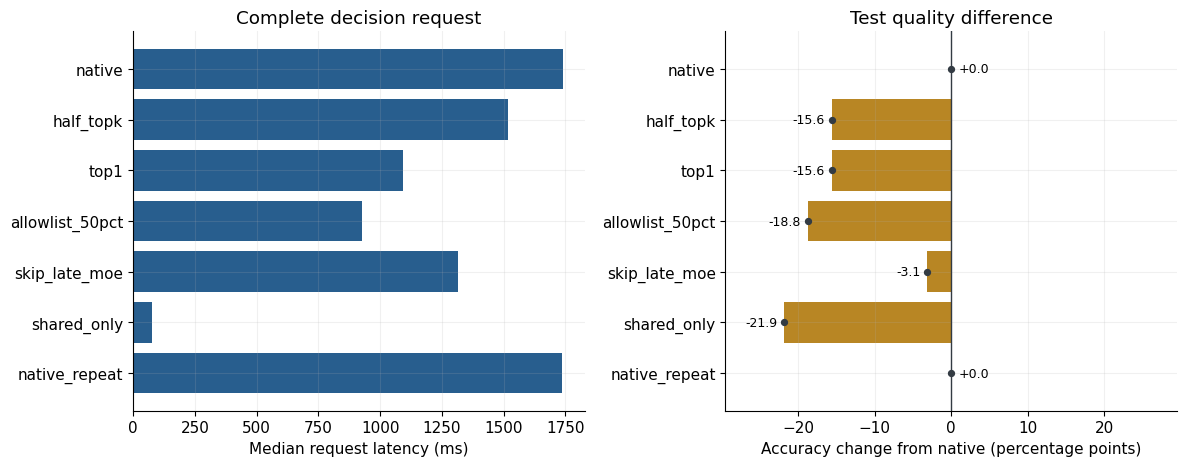

In [13]:
def comparison_table():
    df=pd.DataFrame(RESULTS)
    native=df.loc[df.arm=='native'].iloc[0]
    df['speedup_p50']=native.p50_ms/df.p50_ms
    df['accuracy_delta_pp']=100*(df.accuracy-native.accuracy)
    df['nll_delta']=df.nll-native.nll
    flips=[]; gaps=[]
    for name in df.arm:
        tests=[x for x in PREDICTIONS[name] if x['split']=='test']
        flips.append(float(np.mean([np.argmax(x['logits'])!=np.argmax(base_by_id[x['id']]['logits']) for x in tests])))
        gaps.append(max(float(np.max(np.abs(probs(x['logits'])-probs(base_by_id[x['id']]['logits'])))) for x in tests))
    df['native_disagreement']=flips; df['max_probability_shift_raw']=gaps
    df.to_csv(RUN_DIR/'comparison.csv',index=False)
    return df

comparison=comparison_table()
display(comparison[['arm','accuracy','accuracy_delta_pp','nll','false_none','coverage','accepted_error',
                    'p50_ms','p95_ms','speedup_p50','peak_allocated_gib','native_disagreement']].round(4))
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4.8))
ax1.barh(comparison.arm,comparison.p50_ms,color=BLUE)
ax1.set(xlabel='Median request latency (ms)',title='Complete decision request')
ax1.invert_yaxis()
ax2.barh(comparison.arm,comparison.accuracy_delta_pp,color=GOLD)
ax2.axvline(0,color=CHARCOAL,lw=1)
ax2.set(xlabel='Accuracy change from native (percentage points)',title='Test quality difference')
ax2.invert_yaxis()
span=max(2.0,float(comparison.accuracy_delta_pp.abs().max())*1.35)
ax2.set_xlim(-span,span)
ax2.scatter(comparison.accuracy_delta_pp,np.arange(len(comparison)),color=CHARCOAL,s=18,zorder=3)
for j,value in enumerate(comparison.accuracy_delta_pp):
    ax2.annotate(f'{value:+.1f}',(value,j),xytext=(5 if value>=0 else -5,0),textcoords='offset points',
                 va='center',ha='left' if value>=0 else 'right',fontsize=9)
if SMOKE: fig.suptitle('SMOKE ONLY — random tiny weights; no pretrained quality or speed claim')
fig.tight_layout(); fig.savefig(RUN_DIR/'quality_latency.png',dpi=150); plt.show()
# Per-family/class strata are small; exact counts remain visible.
slices=[]
for arm,preds in PREDICTIONS.items():
    result=next(x for x in RESULTS if x['arm']==arm)
    tests=[x for x in preds if x['split']=='test']
    for family in sorted({x['family'] for x in tests}):
        part=[x for x in tests if x['family']==family]
        slices.append({'arm':arm,'family':family,'n':len(part),
                       'correct':sum(row_outcome(x,result['temperature'])[3] for x in part)})
pd.DataFrame(slices).to_csv(RUN_DIR/'family_counts.csv',index=False)

## 10. Does a direct readout avoid measurable work?

Both paths evaluate the same complete prompt. `full` projects the last position to the entire vocabulary; `selected` projects only the offered answer codes. Neither generates text. Verify the full/selected distributions across test inputs before attributing a speed difference to this optimization. Repeated, alternating measurements reduce order bias.

In [14]:
readout_samples=[]; readout_differences=[]
readout_rows=[r for r in ROWS if r['split']=='test'][:(4 if SMOKE else 8)]
for r in readout_rows:
    for rep in range(max(2,TIMING_REPEATS)):
        order=['full','selected'] if rep%2==0 else ['selected','full']
        scores={}
        for mode in order:
            (z,n),ms=measure_call(lambda r=r,mode=mode:decision(r,mode))
            scores[mode]=z
            readout_samples.append({'id':r['id'],'readout':mode,'ms':ms,'input_tokens':n})
        delta=float(np.max(np.abs(probs(scores['full'])-probs(scores['selected']))))
        same=bool(np.argmax(scores['full'])==np.argmax(scores['selected']))
        readout_differences.append({'id':r['id'],'max_dp':delta,'decision_match':same})
save_json('readout_comparison.json',{'timings':readout_samples,'parity':readout_differences})
assert all(x['max_dp']<=0.005 and x['decision_match'] for x in readout_differences)
display(pd.DataFrame(readout_samples).groupby('readout').ms.agg(['count','median','max']).round(3))
print('Vocabulary projection check passed on the measured items. Resident embeddings/weights were retained.')

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,count,median,max
readout,,,
full,16,1733.951,1762.323
selected,16,1728.837,1754.430


Vocabulary projection check passed on the measured items. Resident embeddings/weights were retained.


### Context length: do sparse tokens still touch many experts?

Append explicitly irrelevant archive entries to one routing-fit example and record the **actual full-prompt length**. This controlled synthetic stress test measures expert coverage, native versus half-k latency, and peak allocation. It is not an accuracy benchmark or evidence that repeated filler represents real documents. Inputs above the declared cap are recorded as rejected. Use your own varied documents for the next study.

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,mode,input_tokens,extra_context_tokens_requested,p50_ms,peak_allocated_gib,native_mean_unique_experts,native_mean_expert_fraction
0,native,117,0,1690.782,7.819,59.208,0.987
1,half_topk,117,0,1485.590,7.819,59.208,0.987
2,native,245,128,1760.209,7.824,59.708,0.995
3,half_topk,245,128,1607.639,7.824,59.708,0.995
4,native,629,512,1745.301,7.867,59.750,0.996
5,half_topk,629,512,1654.279,7.867,59.750,0.996


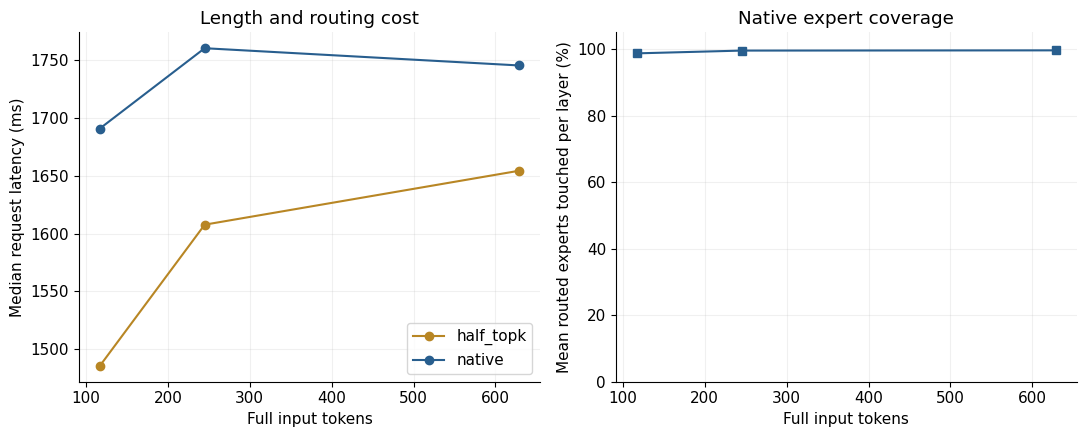

In [15]:
length_rows=[]; length_rejections=[]
if RUN_LENGTH_STUDY:
    for extra_budget in EXTRA_CONTEXT_TOKENS:
        filler=''
        while len(tokenizer.encode(filler,add_special_tokens=False))<extra_budget:
            filler+='\nArchive note: this unrelated inventory card has a gray border and no case facts.'
        item=dict(probe,id=probe['id']+f'-length-{extra_budget}',state=probe['state']+filler)
        try: actual_tokens=len(prepare(item)[0])
        except ValueError as exc:
            length_rejections.append({'extra_context_tokens_requested':extra_budget,'reason':str(exc)})
            continue
        with RoutingTrace() as length_trace:
            length_trace.current_id=item['id']; decision(item)
        mean_unique=float(np.mean([x['unique_experts'] for x in length_trace.records]))
        for name,k in [('native',config.num_experts_per_tok),('half_topk',half_k)]:
            with intervention(top_k=k):
                decision(item); sync()
                if DEVICE.type=='cuda': torch.cuda.reset_peak_memory_stats(DEVICE)
                samples=[measure_call(lambda:decision(item))[1] for _ in range(max(2,TIMING_REPEATS))]
                peak=torch.cuda.max_memory_allocated(DEVICE)/2**30 if DEVICE.type=='cuda' else None
            length_rows.append({'mode':name,'input_tokens':actual_tokens,
                'extra_context_tokens_requested':extra_budget,'p50_ms':float(np.median(samples)),
                'peak_allocated_gib':peak,'native_mean_unique_experts':mean_unique,
                'native_mean_expert_fraction':mean_unique/config.num_experts})
    save_json('length_study.json',{'measurements':length_rows,'rejected':length_rejections,
                                 'scope':'synthetic filler on a routing-fit item; no quality claim'})
    length_df=pd.DataFrame(length_rows)
    if not length_df.empty:
        display(length_df.round(3))
        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11,4.5))
        for mode,part in length_df.groupby('mode'):
            ax1.plot(part.input_tokens,part.p50_ms,marker='o',label=mode,
                     color=BLUE if mode=='native' else GOLD)
        native_lengths=length_df[length_df['mode']=='native']
        ax2.plot(native_lengths.input_tokens,native_lengths.native_mean_expert_fraction*100,
                 color=BLUE,marker='s')
        ax1.set(xlabel='Full input tokens',ylabel='Median request latency (ms)',title='Length and routing cost')
        ax1.legend()
        ax2.set(xlabel='Full input tokens',ylabel='Mean routed experts touched per layer (%)',
                title='Native expert coverage',ylim=(0,105))
        if SMOKE: fig.suptitle('SMOKE ONLY — random tiny weights and synthetic filler')
        fig.tight_layout(); fig.savefig(RUN_DIR/'length_study.png',dpi=150); plt.show()
    if length_rejections: print('Length-study input rejections:',length_rejections)
else:
    print('Length study disabled.')

## 11. Share exact prefix state across independent questions

The common prefix is computed from **finalized token IDs**. Each question receives a deep copy of the native cache, with explicit absolute positions and a mask covering prefix + suffix. Cold shared time includes prefix computation; warm time includes branch copying but assumes a resident prefix. These classical Qwen caches do not qualify Qwen3.5's hybrid state.

**Parity is a gate, not a guaranteed result.** Before timing, compare full execution, a full repeat, full execution with caching enabled, cold split execution, warm split execution, and reversed question order. Check cache storage independence and hash its contents before/after branching. The gate retains **maximum option-probability difference ≤ 0.005 and identical decisions**. If it fails, write the diagnostics, disable the cache comparison and suffix-policy experiment, and continue with section 12. No failed cache path contributes a speedup claim.

Splitting an input changes matrix shapes and potentially numerical results ([PyTorch numerical accuracy](https://docs.pytorch.org/docs/stable/notes/numerical_accuracy.html)). With quantization and discrete MoE routing, numerical sensitivity is a hypothesis to investigate, not a diagnosis from an assertion alone. The bitsandbytes `_check_is_size` FutureWarning is separate from the parity gate. Do not increase the tolerance to hide a failure.

| Diagnostic result | Next investigation |
|---|---|
| Full vs repeat fails | Establish repeatability of the baseline before evaluating reuse. |
| Full vs full-cache fails | Isolate the cache-enabled forward call and its mask/position settings. |
| Reordering fails, storage aliases, or the root hash changes | Investigate cache isolation and state mutation. |
| Only full vs split fails | Shape/precision sensitivity remains a candidate. Compare a separately recorded higher-precision run if it fits; this does not prove the NF4 path equivalent. |

The gate checks every calibration, policy-development and test group needed by the suffix experiment, stopping at the first failing group. It uses **no labels**. Passing is scoped to these inputs and this runtime. The half-k suffix arm deliberately changes the model policy and gets its own temperature/review fits; it is never labeled equivalent to native routing.

**Resume an older run:** run `OpenKind_prefix_parity_fix.py` in the existing notebook namespace at the failed section, then continue at section 12. Do this before terminal weight removal. It keeps the loaded model and earlier results, and archives the old prefix diagnostics. Share `cache_diagnostics.json` to investigate a failure; it contains option logits and IDs, not source-state text.

In [16]:
CACHE_PARITY_TOL = 0.005  # Same gate as v0.1; not relaxed for NF4.
if MODEL_PRUNED:
    raise RuntimeError('Section 11 needs the intact model. Reload after terminal weight removal.')
assert all(b.top_k == config.num_experts_per_tok for _, b in MOES), 'Restore native routing first.'

def common_prefix(token_lists):
    n=min(map(len,token_lists))
    for j in range(n):
        if len({x[j] for x in token_lists})>1: return token_lists[0][:j]
    return token_lists[0][:max(0,n-1)]

@torch.inference_mode()
def cache_forward(ids, cache=None):
    # All inputs are unpadded, batch size one. Only unprocessed IDs enter this call.
    start=0 if cache is None else int(cache.get_seq_length())
    position=torch.arange(start,start+len(ids),device=DEVICE,dtype=torch.long)
    return model.model(
        input_ids=torch.tensor([ids],device=DEVICE,dtype=torch.long),
        attention_mask=torch.ones((1,start+len(ids)),device=DEVICE,dtype=torch.long),
        position_ids=position.unsqueeze(0), cache_position=position,
        past_key_values=cache, use_cache=True, return_dict=True, output_router_logits=False)

@torch.inference_mode()
def cache_logits(out, codes):
    ix=torch.tensor(codes,device=DEVICE,dtype=torch.long)
    weights=model.lm_head.weight.index_select(0,ix)
    bias=model.lm_head.bias.index_select(0,ix) if model.lm_head.bias is not None else None
    z=F.linear(out.last_hidden_state[0,-1].to(weights.dtype),weights,bias).float().cpu().numpy()
    if not np.isfinite(z).all(): raise FloatingPointError('Non-finite cache-path answer logits')
    return z

@torch.inference_mode()
def full_cache_score(r):
    ids,codes=prepare(r)
    return cache_logits(cache_forward(ids),codes)

@torch.inference_mode()
def build_root(prefix):
    assert prefix, 'No shared tokens'
    root=cache_forward(prefix).past_key_values
    assert int(root.get_seq_length())==len(prefix)
    return root

@torch.inference_mode()
def shared_scores(rows,prefix,suffix_k=None,root=None):
    prepared=[prepare(r) for r in rows]
    assert all(ids[:len(prefix)]==prefix and len(ids)>len(prefix) for ids,_ in prepared)
    if root is None: root=build_root(prefix)
    start_length=int(root.get_seq_length())
    assert start_length==len(prefix), 'Cache length does not match exact token prefix'
    output=[]
    settings={} if suffix_k is None else {'top_k':suffix_k}
    with intervention(**settings):
        for ids,codes in prepared:
            branch=copy.deepcopy(root)
            out=cache_forward(ids[len(prefix):],cache=branch)
            assert int(out.past_key_values.get_seq_length())==len(ids)
            output.append(cache_logits(out,codes))
            del out,branch
    assert int(root.get_seq_length())==start_length, 'Shared cache length was mutated'
    return output

def cache_tensors(cache):
    # Pinned Transformers 4.57.1 DynamicCache; inspect every layer, outside timing.
    return [t for layer in cache.layers for t in (layer.keys,layer.values) if t is not None]

def cache_fingerprint(cache):
    h=hashlib.sha256()
    for t in cache_tensors(cache):
        h.update(str((tuple(t.shape),str(t.dtype))).encode())
        h.update(t.detach().contiguous().view(torch.uint8).cpu().numpy().tobytes())
    return {'length':int(cache.get_seq_length()),'sha256':h.hexdigest()}

def compare_cache_logits(a,b):
    delta=float(np.max(np.abs(probs(a)-probs(b))))
    match=bool(np.argmax(a)==np.argmax(b))
    return {'max_dp':delta,'decision_match':match,'passed':delta<=CACHE_PARITY_TOL and match}

def diagnose_cache_group(group):
    prefix=common_prefix([prepare(r)[0] for r in group])
    reference=[decision(r)[0] for r in group]
    repeat=[decision(r)[0] for r in group]
    full_cached=[full_cache_score(r) for r in group]
    root=build_root(prefix)
    before=cache_fingerprint(root)
    branch=copy.deepcopy(root)
    left,right=cache_tensors(root),cache_tensors(branch)
    independent=bool(left) and len(left)==len(right) and all(
        a.data_ptr()!=b.data_ptr() for a,b in zip(left,right))
    del branch,left,right
    warm=shared_scores(group,prefix,root=root)
    reversed_scores=shared_scores(list(reversed(group)),prefix,root=root)[::-1]
    cold=shared_scores(group,prefix)
    unchanged=cache_fingerprint(root)==before
    del root
    checks=[]
    for r,a,b,c,d,e,f in zip(group,reference,repeat,full_cached,warm,reversed_scores,cold):
        comparisons={
            'full_vs_repeat':compare_cache_logits(a,b),
            'full_vs_full_cache':compare_cache_logits(a,c),
            'full_vs_warm_split':compare_cache_logits(a,d),
            'full_vs_cold_split':compare_cache_logits(a,f),
            'warm_vs_reordered':compare_cache_logits(d,e),
            'full_vs_reordered':compare_cache_logits(a,e)}
        p=probs(a); order=np.sort(p)
        paths={'full':a,'repeat':b,'full_cache':c,'warm_split':d,'reordered':e,'cold_split':f}
        checks.append({
            'id':r['id'],'state_id':r['state_id'],'split':r['split'],
            'prefix_tokens':len(prefix),'input_tokens':len(prepare(r)[0]),
            'option_ids':[o['id'] for o in r['options']],
            'reference_margin':float(order[-1]-order[-2]),
            'max_dp':max(x['max_dp'] for x in comparisons.values()),
            'decision_match':all(x['decision_match'] for x in comparisons.values()),
            'cache_storage_independent':independent,'root_cache_unchanged':unchanged,
            'passed':independent and unchanged and all(x['passed'] for x in comparisons.values()),
            'comparisons':comparisons,
            'logits':{k:v.tolist() for k,v in paths.items()},
            'probabilities':{k:probs(v).tolist() for k,v in paths.items()}})
    return checks

def cache_status_summary():
    return {k:cache_report[k] for k in (
        'status','tolerance','checked_rows','planned_rows','max_dp','decision_flips',
        'failed_comparisons','cache_integrity_failed','error','scope')}

In [17]:
def run_shared_study():
    groups=defaultdict(list)
    for r in EVAL_ROWS: groups[r['state_id']].append(r)
    groups={sid:sorted(group,key=lambda r:r['id']) for sid,group in groups.items()}
    checks=[]; error=None
    for sid,group in groups.items():
        try:
            part=diagnose_cache_group(group)
            checks.extend(part)
        except Exception as exc:
            # Preserve a failed cache experiment without claiming it was validated.
            error={'state_id':sid,'type':type(exc).__name__,'message':str(exc)}
            break
        finally:
            save_json('shared_prefix_parity.json',checks)
        if not all(x['passed'] for x in part): break
    passed=bool(checks) and error is None and len(checks)==len(EVAL_ROWS) and all(x['passed'] for x in checks)
    status='passed' if passed else ('error' if error else 'failed')
    report={
        'status':status,'tolerance':CACHE_PARITY_TOL,'checked_rows':len(checks),'planned_rows':len(EVAL_ROWS),
        'max_dp':max((x['max_dp'] for x in checks),default=None),
        'decision_flips':sum(not x['decision_match'] for x in checks),
        'failed_comparisons':sorted({k for x in checks for k,v in x['comparisons'].items() if not v['passed']}),
        'cache_integrity_failed':any(not(x['cache_storage_independent'] and x['root_cache_unchanged']) for x in checks),
        'error':error,'scope':'All EVAL_ROWS groups; stop at first failing group; no labels used',
        'runtime':{'profile':PROFILE,'precision_requested':PRECISION,'model_revision':REVISION,
                   'model_dtype':str(model.dtype),'torch':torch.__version__,
                   'transformers':transformers.__version__,
                   'bitsandbytes':metadata.version('bitsandbytes') if DEVICE.type=='cuda' else None,
                   'gpu':torch.cuda.get_device_name(DEVICE) if DEVICE.type=='cuda' else None},
        'checks':checks}
    save_json('cache_diagnostics.json',report)
    columns=['state_id','q','mode','repeat','prefix_tokens','request_ms','ms_per_decision',
             'parity_status','equivalent_to_native']
    samples=[]
    # Always create a schema-valid output, even when the cache comparison is disabled.
    pd.DataFrame(samples,columns=columns).to_csv(RUN_DIR/'shared_request_timings.csv',index=False)
    if not passed:
        print('Cache parity:',status.upper(), '— cache timing and suffix-policy experiments disabled.')
        print('Diagnostics:',RUN_DIR/'cache_diagnostics.json')
        print('Continue at section 12. The full-input experiments remain separate.')
        return pd.DataFrame(samples,columns=columns),report
    for sid,group in [(sid,g) for sid,g in groups.items() if g[0]['split']=='test'][:2]:
        prefix=common_prefix([prepare(r)[0] for r in group])
        root=build_root(prefix)
        for q in sorted({min(x,len(group)) for x in [1,2,4]}):
            subset=group[:q]
            modes={
                'repeated_full':lambda:[decision(r)[0] for r in subset],
                'cold_shared':lambda:shared_scores(subset,prefix),
                'warm_shared':lambda:shared_scores(subset,prefix,root=root),
                'warm_half_k_suffix':lambda:shared_scores(subset,prefix,suffix_k=half_k,root=root)}
            for fn in modes.values(): fn()
            for rep in range(max(2,TIMING_REPEATS)):
                order=list(modes)
                if rep%2: order.reverse()
                for mode in order:
                    _,ms=measure_call(modes[mode])
                    samples.append({'state_id':sid,'q':q,'mode':mode,'repeat':rep,
                        'prefix_tokens':len(prefix),'request_ms':ms,'ms_per_decision':ms/q,
                        'parity_status':'passed_on_checked_inputs',
                        'equivalent_to_native':mode!='warm_half_k_suffix'})
            pd.DataFrame(samples,columns=columns).to_csv(RUN_DIR/'shared_request_timings.csv',index=False)
        del root
    return pd.DataFrame(samples,columns=columns),report

shared_df,cache_report=run_shared_study()
display(pd.DataFrame([cache_status_summary()]).drop(columns=['error','scope']).T)
if cache_report['checks'] and cache_report['status']!='passed':
    display(pd.DataFrame(cache_report['checks']).sort_values('max_dp',ascending=False)[
        ['id','max_dp','decision_match','reference_margin','root_cache_unchanged']].head(8))

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Cache parity: FAILED — cache timing and suffix-policy experiments disabled.
Diagnostics: /content/openkind_moe_runs/20260926T232551_755243Z/cache_diagnostics.json
Continue at section 12. The full-input experiments remain separate.


,0
status,failed
tolerance,0.005
checked_rows,4
planned_rows,64
max_dp,0.061671
decision_flips,0
failed_comparisons,"[full_vs_cold_split, full_vs_reordered, full_v..."
cache_integrity_failed,False


,id,max_dp,decision_match,reference_margin,root_cache_unchanged
2,calibration-document-8-q2,0.061671,True,0.183081,True
3,calibration-document-8-q3,0.013944,True,0.773956,True
0,calibration-document-8-q0,0.003027,True,0.990042,True
1,calibration-document-8-q1,0.002356,True,0.989136,True


In [18]:
def evaluate_suffix_policy():
    if cache_report['status']!='passed':
        result={'arm':'native_prefix_half_k_suffix','status':'SKIPPED_CACHE_PARITY',
                'reason':'Native cache path did not qualify; no quality or speedup claim.'}
        save_json('suffix_policy.json',{'result':result,'predictions':[]})
        return result
    predictions=[]
    groups=defaultdict(list)
    for r in EVAL_ROWS: groups[r['state_id']].append(r)
    for group in groups.values():
        group=sorted(group,key=lambda r:r['id'])
        prefix=common_prefix([prepare(r)[0] for r in group])
        logits=shared_scores(group,prefix,suffix_k=half_k)
        for r,z in zip(group,logits):
            keys=[o['id'] for o in r['options']]
            predictions.append({'id':r['id'],'state_id':r['state_id'],'family':r['family'],'split':r['split'],
              'target_id':r['target_id'],'none_id':r['none_id'],'option_ids':keys,
              'target_index':keys.index(r['target_id']),'logits':z.tolist()})
    T=fit_temperature([x for x in predictions if x['split']=='calibration'])
    threshold=fit_review_threshold([x for x in predictions if x['split']=='policy_dev'],T)
    result={'arm':'native_prefix_half_k_suffix','status':'EXPLORATORY_CHANGED_POLICY',
            'temperature':T,'review_threshold':threshold,
            **summarize([x for x in predictions if x['split']=='test'],T,threshold)}
    save_json('suffix_policy.json',{'result':result,'predictions':predictions})
    return result

suffix_result=evaluate_suffix_policy()
display(pd.DataFrame([suffix_result]).round(4))
if shared_df.empty:
    shared_summary=pd.DataFrame(columns=['mode','q','count','median','max'])
    # Remove a stale image if section 11 is rerun after an earlier successful run.
    (RUN_DIR/'shared_prefix_cost.png').unlink(missing_ok=True)
    print('No cache speedup chart: parity has not passed.')
else:
    shared_summary=shared_df.groupby(['mode','q']).request_ms.agg(['count','median','max']).reset_index()
    display(shared_summary.round(3))
    fig,ax=plt.subplots(figsize=(9,4.5))
    styles={'repeated_full':(CHARCOAL,'o','-'),'cold_shared':(BLUE,'s','--'),
            'warm_shared':(GOLD,'^','-'),'warm_half_k_suffix':(ORANGE,'D',':')}
    for mode,part in shared_summary.groupby('mode'):
        color,marker,line=styles[mode]
        label=mode if mode!='warm_half_k_suffix' else 'warm half-k suffix (changed policy)'
        ax.plot(part.q,part['median'],label=label,color=color,marker=marker,linestyle=line)
    ax.set(xlabel='Questions over the same state',ylabel='Median complete group request (ms)',
           title=('SMOKE ONLY — ' if SMOKE else '')+'Prefix reuse: native cache parity passed')
    ax.set_xticks(sorted(shared_summary.q.unique())); ax.legend(fontsize=9)
    fig.tight_layout(); fig.savefig(RUN_DIR/'shared_prefix_cost.png',dpi=150); plt.show()
gc.collect()

,arm,status,reason
0,native_prefix_half_k_suffix,SKIPPED_CACHE_PARITY,Native cache path did not qualify; no quality ...


No cache speedup chart: parity has not passed.


30

## 12. Option-order robustness

Use the native weights and the fitted native temperature. Reverse the offered options, map probabilities back to semantic IDs, and report changes without selecting another prompt. This tests one permutation, not full order invariance. Router sparsification should eventually pass the same check on independent data.

In [19]:
order_checks=[]
native_temperature=next(x['temperature'] for x in RESULTS if x['arm']=='native')
for r in [x for x in ROWS if x['split']=='test'][:(4 if SMOKE else 12)]:
    original,_=decision(r)
    permuted=dict(r,options=list(reversed(r['options'])))
    shifted,_=decision(permuted)
    p1={o['id']:float(p) for o,p in zip(r['options'],probs(original,native_temperature))}
    p2={o['id']:float(p) for o,p in zip(permuted['options'],probs(shifted,native_temperature))}
    order_checks.append({'id':r['id'],'semantic_choice_changed':max(p1,key=p1.get)!=max(p2,key=p2.get),
                         'max_semantic_probability_shift':max(abs(p1[k]-p2[k]) for k in p1)})
save_json('option_order_check.json',order_checks)
display(pd.DataFrame(order_checks))

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,id,semantic_choice_changed,max_semantic_probability_shift
0,test-document-13-q0,False,0.046287
1,test-document-13-q1,True,0.106142
2,test-document-13-q2,False,0.205737
3,test-document-13-q3,False,0.093945
4,test-document-14-q0,False,0.137713
5,test-document-14-q1,False,0.232657
6,test-document-14-q2,True,0.386630
7,test-document-14-q3,False,0.115444
8,test-document-15-q0,False,0.009804
9,test-document-15-q1,False,0.038455


## 13. Streaming feasibility from observed routes

This section is a **simulation**, not a streamed-model benchmark. It replays each layer's observed expert union in ascending expert-ID order, matching the inspected reference dispatch loop. Cache slots are global `(layer, expert)` entries. The trace comes from the routing-fit workload and assumes fixed routes: stale traces do not model feedback after pruning.

The simulator counts cold misses and repeated-pass misses, then estimates transfer-only time as missed payload bytes divided by bandwidth. It excludes host capacity, storage I/O, scheduling, dequantization, compute overlap and real kernel behavior. A transfer microbenchmark, when available, measures a contiguous pinned-host copy rather than actual expert execution. On Apple Silicon, unified memory changes the bottleneck; these PCIe estimates are not Mac predictions.

,cache_expert_slots,pass,requests,misses,hit_rate,payload_gib,bandwidth_GB_per_s,transfer_only_seconds,bandwidth_kind
0,0,1,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
4,0,2,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
8,180,1,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
12,180,2,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
16,360,1,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
20,360,2,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
24,720,1,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
28,720,2,22784,22784,0.0000,94.7637,8.0,12.7190,scenario
32,1440,1,22784,1440,0.9368,5.9893,8.0,0.8039,scenario
36,1440,2,22784,0,1.0000,0.0000,8.0,0.0000,scenario


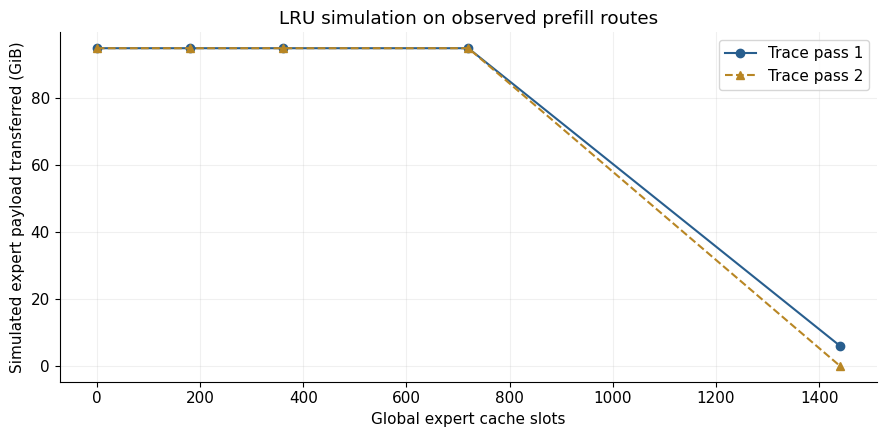

In [20]:
def payload_storage_bytes(module):
    """Count tensor storage, including common bitsandbytes quantization state, once per expert."""
    seen_obj=set(); seen_storage=set(); total=0
    def visit(obj):
        nonlocal total
        if obj is None or id(obj) in seen_obj: return
        seen_obj.add(id(obj))
        if isinstance(obj,torch.Tensor):
            storage=obj.untyped_storage()
            key=(str(obj.device),storage.data_ptr(),storage.nbytes())
            if key not in seen_storage: seen_storage.add(key); total+=storage.nbytes()
            if hasattr(obj,'quant_state'): visit(obj.quant_state)
        elif isinstance(obj,(tuple,list)):
            for v in obj: visit(v)
        elif isinstance(obj,dict):
            for v in obj.values(): visit(v)
        elif hasattr(obj,'__dict__') and type(obj).__name__=='QuantState':
            for v in vars(obj).values(): visit(v)
    for p in module.parameters(): visit(p)
    for b in module.buffers(): visit(b)
    return total

EXPERT_BYTES={(i,j):payload_storage_bytes(expert) for i,b in MOES for j,expert in enumerate(b.experts)}
EVENTS=[(rec['layer'],int(e)) for rec in TRACE for e in rec['expert_ids']]

def simulate_lru(events,capacity):
    cache=OrderedDict(); passes=[]
    for pass_index in range(2):
        misses=0; loaded=0
        for key in events:
            if key in cache: cache.move_to_end(key)
            else:
                misses+=1; loaded+=EXPERT_BYTES[key]
                if capacity>0:
                    cache[key]=True
                    if len(cache)>capacity: cache.popitem(last=False)
        passes.append({'pass':pass_index+1,'requests':len(events),'misses':misses,
                       'hit_rate':1-misses/len(events),'payload_gib':loaded/2**30})
    return passes

bandwidths=list(TRANSFER_BANDWIDTH_GBPS)
measured_bw=None
if DEVICE.type=='cuda':
    nbytes=16*2**20
    host=torch.zeros(nbytes,dtype=torch.uint8,pin_memory=True)
    dest=torch.empty(nbytes,dtype=torch.uint8,device=DEVICE)
    for _ in range(2): dest.copy_(host,non_blocking=True); sync()
    copy_times=[]
    for _ in range(8):
        _,ms=measure_call(lambda:dest.copy_(host,non_blocking=True))
        copy_times.append(ms)
    measured_bw=nbytes/(np.median(copy_times)/1000)/1e9
    bandwidths.append(float(measured_bw))
    del host,dest
    save_json('host_to_device_microbenchmark.json',{'bytes_per_copy':nbytes,'times_ms':copy_times,
        'median_GB_per_s':float(measured_bw),'scope':'contiguous 16 MiB pinned-host copy; not streaming inference'})
else:
    print('No CUDA transfer measurement; only explicit bandwidth scenarios are shown.')
capacities=sorted({0,max(1,len(EXPERT_BYTES)//8),max(1,len(EXPERT_BYTES)//4),len(EXPERT_BYTES)//2,len(EXPERT_BYTES)})
simulation=[]
for capacity in capacities:
    for result in simulate_lru(EVENTS,capacity):
        for bw in bandwidths:
            simulation.append({'cache_expert_slots':capacity,**result,'bandwidth_GB_per_s':bw,
                'transfer_only_seconds':result['payload_gib']*2**30/(bw*1e9),
                'bandwidth_kind':'copy_microbenchmark' if measured_bw is not None and bw==measured_bw else 'scenario'})
sim_df=pd.DataFrame(simulation)
sim_df.to_csv(RUN_DIR/'streaming_simulation.csv',index=False)
display(sim_df[sim_df.bandwidth_GB_per_s==bandwidths[0]].round(4))
fig,ax=plt.subplots()
scale=1024 if sim_df.payload_gib.max()<1 else 1
unit='MiB' if scale==1024 else 'GiB'
for pass_no,part in sim_df[sim_df.bandwidth_GB_per_s==bandwidths[0]].groupby('pass'):
    ax.plot(part.cache_expert_slots,part.payload_gib*scale,marker='o' if pass_no==1 else '^',
            linestyle='-' if pass_no==1 else '--',label=f'Trace pass {pass_no}',
            color=BLUE if pass_no==1 else GOLD)
ax.set(xlabel='Global expert cache slots',ylabel=f'Simulated expert payload transferred ({unit})',
       title=('SMOKE routes — ' if SMOKE else '')+'LRU simulation on observed prefill routes')
ax.legend(); fig.tight_layout(); fig.savefig(RUN_DIR/'streaming_simulation.png',dpi=150); plt.show()

## 14. Physical expert removal: measure actual residency

**Terminal model mutation:** after this cell, unrestricted arms require reloading section 5. The allowlist's excluded experts are replaced by parameter-free modules that raise if called. The original expert objects are not retained elsewhere. This should preserve the already-masked model's outputs while allowing their device storage to be reclaimed. It does **not** preserve the native model's quality automatically.

The reference model must fit before this experiment starts. This is not a low-memory checkpoint loader or an expert-streaming runtime. GPU allocated bytes measure reclamation; reserved bytes require allocator cleanup; RSS is only a snapshot. The exported allowlist is a reconstruction manifest, not a stock-Hugging-Face-loadable pruned checkpoint.

In [21]:
class ForbiddenExpert(torch.nn.Module):
    def forward(self,*args,**kwargs):
        raise RuntimeError('A removed expert was selected; allowlist contract failed.')

def remove_excluded_experts():
    global MODEL_PRUNED
    if MODEL_PRUNED: raise RuntimeError('Already pruned; reload before repeating this experiment.')
    before=memory_snapshot(); removed_bytes=0; removed_count=0
    for layer,block in MOES:
        keep=set(ALLOWLISTS[layer])
        for expert_id in range(len(block.experts)):
            if expert_id not in keep:
                removed_bytes+=EXPERT_BYTES[(layer,expert_id)]
                block.experts[expert_id]=ForbiddenExpert()
                removed_count+=1
    MODEL_PRUNED=True
    gc.collect(); sync()
    if DEVICE.type=='cuda': torch.cuda.empty_cache()
    after=memory_snapshot()
    return {'before':before,'after':after,'removed_expert_modules':removed_count,
            'sum_removed_expert_payload_gib':removed_bytes/2**30,
            'allocated_reclaimed_gib':before['cuda_allocated_gib']-after['cuda_allocated_gib'] if DEVICE.type=='cuda' else None,
            'interpretation':'payload sums can include small shared quantization tables; measured allocated delta is authoritative'}

pruning_report=None
if RUN_WEIGHT_REMOVAL:
    pruning_report=remove_excluded_experts()
    save_json('physical_removal.json',pruning_report)
    run_arm(ALLOWLIST_ARM+'_removed',{'allowlists':ALLOWLISTS})
    prior={x['id']:x for x in PREDICTIONS[ALLOWLIST_ARM]}
    matches=[]
    for x in PREDICTIONS[ALLOWLIST_ARM+'_removed']:
        old=prior[x['id']]
        matches.append({'id':x['id'],
            'max_dp':float(np.max(np.abs(probs(x['logits'])-probs(old['logits'])))),
            'decision_match':bool(np.argmax(x['logits'])==np.argmax(old['logits']))})
    save_json('physical_removal_parity.json',matches)
    assert all(x['max_dp']<=0.005 and x['decision_match'] for x in matches), 'Removal changed masked behavior'
    display(pd.DataFrame([pruning_report['before'],pruning_report['after']],index=['masked, weights resident','excluded weights removed']))
    print('Removed modules:',pruning_report['removed_expert_modules'])
    comparison=comparison_table()
else:
    print('Weight removal disabled; masking results alone do not demonstrate resident-memory savings.')

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


allowlist_50pct_removed: accuracy=0.375, p50=945.9 ms, p95=964.4 ms


,cuda_allocated_gib,cuda_reserved_gib,process_rss_gib
"masked, weights resident",7.807611,10.599609,2.580395
excluded weights removed,4.797220,10.544922,2.580395


Removed modules: 720


## 15. Read results and export the run

Use the saved evidence to answer these questions in order:

1. **Correctness:** did the native repeat, selected-row projection and cache checks pass? Which gold-label families or semantic-none cases fail?
2. **Routing:** how many distinct experts did whole prefills touch? Did lower top-k actually reduce wall time?
3. **Preservation:** how did accuracy, false-none, NLL/Brier and policy coverage change? Is the specialist subset merely memorizing these fixture families?
4. **Memory:** was the change in allocated weight memory, cache/activation peak, allocator reservation, or only an estimated active-parameter count?
5. **Deployment:** does a candidate beat an accepted dense-Qwen baseline at the same quality/resource limits on new grouped data?

A follow-up should lock one promising intervention and validate it on independently sourced documents, longer inputs, shifted question families and multiple option counts. Compare FP32/BF16/NF4 only through separately recorded runs. A smaller expert subset may need training or distillation; no recovery is assumed here. An early-layer logit probe would additionally need a trained/calibrated readout—skipping late MoE blocks is not that experiment.

**Mac handoff:** reuse the dataset, allowed-token contract, chosen expert IDs, per-layer routes and parity fixtures. Measure Rust/MLX locally, including hybrid state if adopting Qwen3.5. CUDA Python-hook speedups, PCIe simulations and bitsandbytes storage do not establish MLX/GGUF gains. Keep the previous confirmed paper unchanged until a measured study earns an evidence entry.

In [22]:
comparison=comparison_table()
cols=['arm','accuracy','nll','false_none','coverage','accepted_error','p50_ms','p95_ms','peak_allocated_gib','speedup_p50']
display(comparison[cols].round(4))
# Explicit status instead of declaring a winner from a small teaching set.
summary={'status':('SMOKE_ONLY' if SMOKE else
                   'EXPLORATORY_COMPLETE' if cache_report['status']=='passed' else
                   'EXPLORATORY_COMPLETE_CACHE_DISABLED'),
         'cache_parity':cache_status_summary(),
         'cache_optimizations_enabled':cache_report['status']=='passed',
         'data_kind':DATA_KIND,'model_id':MANIFEST['model_id'],'model_revision':REVISION,
         'completed_arms':[x['arm'] for x in RESULTS],
         'native_repeat_max_dp':repeat_diff,'native_repeat_flips':int(repeat_flips),
         'suffix_policy':suffix_result,'physical_removal':pruning_report,
         'limitations':['No fresh production/generalization claim from authored fixtures',
                        'Python eager reference, not optimized serving-engine maximum',
                        'No actual streamed-model or Qwen3.5 inference in this notebook',
                        'No training, model promotion, or OpenKind protected-final access']}
save_json('summary.json',summary)
MANIFEST['completed_utc']=datetime.now(timezone.utc).isoformat()
MANIFEST['completed_arms']=summary['completed_arms']
save_json('manifest.json',MANIFEST)
# Checksums for every run artifact; no checkpoint weights are included.
files=sorted(p for p in RUN_DIR.iterdir() if p.is_file() and p.name!='SHA256SUMS')
(RUN_DIR/'SHA256SUMS').write_text(''.join(hashlib.sha256(p.read_bytes()).hexdigest()+'  '+p.name+'\n' for p in files))
archive=shutil.make_archive(str(RUN_DIR),'zip',RUN_DIR)
print('Run status:',summary['status'])
print('Cache parity:',cache_report['status'])
print('Results directory:',RUN_DIR)
print('Evidence archive:',archive)
if SMOKE:
    display(Markdown('**Tiny-model plumbing completed. These outputs do not measure a pretrained Qwen model. Switch to a GPU and rerun for the actual experiment.**'))
elif cache_report['status']!='passed':
    display(Markdown('**Independent experiments completed; cache optimization did not qualify. Inspect cache_diagnostics.json. No cache speedup or suffix-policy quality claim is accepted.**'))
else:
    display(Markdown('**Exploratory run complete. Inspect the quality/resource trade-offs before selecting a follow-up; no production model has been accepted.**'))

,arm,accuracy,nll,false_none,coverage,accepted_error,p50_ms,p95_ms,peak_allocated_gib,speedup_p50
0,native,0.5625,0.9926,0.0000,0.0000,NaN,1740.6467,1771.2634,7.8194,1.0000
1,half_topk,0.4062,1.0353,0.0000,0.0000,NaN,1519.5838,1544.1473,7.8192,1.1455
2,top1,0.4062,1.2205,0.0000,0.2188,0.7143,1090.9885,1130.4085,7.8191,1.5955
3,allowlist_50pct,0.3750,1.2342,0.0000,0.0000,NaN,928.2038,948.1103,7.8194,1.8753
4,skip_late_moe,0.5312,1.0571,0.0000,0.0000,NaN,1316.5890,1344.3305,7.8193,1.3221
5,shared_only,0.3438,1.0993,0.4583,0.0000,NaN,76.1685,79.6812,7.8184,22.8526
6,native_repeat,0.5625,0.9926,0.0000,0.0000,NaN,1735.6917,1754.2339,7.8194,1.0029
7,allowlist_50pct_removed,0.3750,1.2342,0.0000,0.0000,NaN,945.9315,964.4180,4.8247,1.8401


Run status: EXPLORATORY_COMPLETE_CACHE_DISABLED
Cache parity: failed
Results directory: /content/openkind_moe_runs/20260926T232551_755243Z
Evidence archive: /content/openkind_moe_runs/20260926T232551_755243Z.zip


**Independent experiments completed; cache optimization did not qualify. Inspect cache_diagnostics.json. No cache speedup or suffix-policy quality claim is accepted.**

In [23]:
# Optional local download from Colab. Drive-mounted runs already persist in the chosen folder.
DOWNLOAD_ARCHIVE = False  # @param {type:"boolean"}
if DOWNLOAD_ARCHIVE:
    from google.colab import files
    files.download(archive)

## Sources and validation scope

Primary implementation references checked 26 September 2026:

- [Qwen3-30B-A3B-Instruct-2507 model/config](https://huggingface.co/Qwen/Qwen3-30B-A3B-Instruct-2507) and [configuration](https://huggingface.co/Qwen/Qwen3-30B-A3B-Instruct-2507/blob/main/config.json).
- [Qwen1.5-MoE-A2.7B-Chat model/config](https://huggingface.co/Qwen/Qwen1.5-MoE-A2.7B-Chat) and [configuration](https://huggingface.co/Qwen/Qwen1.5-MoE-A2.7B-Chat/blob/main/config.json).
- [Pinned Qwen3 MoE implementation](https://github.com/huggingface/transformers/blob/v4.57.1/src/transformers/models/qwen3_moe/modeling_qwen3_moe.py) and [Qwen2 MoE implementation](https://github.com/huggingface/transformers/blob/v4.57.1/src/transformers/models/qwen2_moe/modeling_qwen2_moe.py).
- [Transformers 4.57.1 cache positions and masks](https://huggingface.co/docs/transformers/v4.57.1/en/cache_explanation).
- [PyTorch numerical accuracy](https://docs.pytorch.org/docs/stable/notes/numerical_accuracy.html).
- [Transformers bitsandbytes documentation](https://huggingface.co/docs/transformers/quantization/bitsandbytes).
- [Qwen3.5 MoE configuration](https://huggingface.co/Qwen/Qwen3.5-35B-A3B/blob/main/config.json) and [5.3.0 packed-expert implementation](https://github.com/huggingface/transformers/blob/v5.3.0/src/transformers/models/qwen3_5_moe/modeling_qwen3_5_moe.py).

**Author validation:** notebook format and Python compilation are checked. Tiny random Qwen2/Qwen3 execution exercises routing interventions, restoration, selected-row parity, prefix branching, calibration/policy accounting, pruning parity and exports. v0.2 additionally tests injected cache-output mismatches: the cache experiment is rejected, its chart is omitted, and later experiments/export still finish. These injections validate failure handling, not the cause of a real GPU discrepancy. Pretrained GPU, NF4 kernels and Colab hardware capacity still require execution in the selected runtime. Run all cells in a fresh GPU session to validate those paths. The saved notebook intentionally contains no fabricated pretrained benchmark outputs.